In [4]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.ticker import ScalarFormatter

from scipy.optimize import curve_fit
from src.plot_style import set_plot_style
from plot_utils import create_figure
from plot_config import with_alpha

set_plot_style()

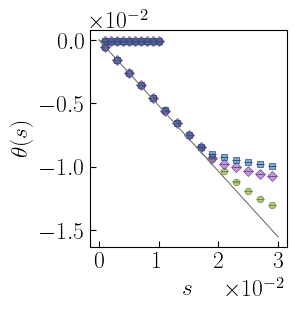

In [ ]:
fig, ax = create_figure(5.0, 5.5, margin_cm=2.0)

with open('figures_data/SCGF_positive_data.json', 'r') as f:
    data = json.load(f)

num_sites_range = np.array([20, 40, 60])
V_values = np.array([5.875, 2.0])

colors = ["#6B8E23", "#7A3E9D", "#1F4E8C"]
colors_soft = with_alpha(colors, 0.5)
marker_map = {20: "o", 40: "D", 60: "s"} 

for n, L in enumerate(num_sites_range):
    marker = marker_map[L]
    for V in V_values:
        print(V)
        s_range = data[f"s_range_V_{V}_L_{L}"]
        SCGF_large_values = data[f"SCGF_positive_V_{V}_L_{L}_large"]
        SCGF_small_values = data[f"SCGF_positive_V_{V}_L_{L}_small"]
        errors = [abs(lv - sv) for lv, sv in zip(SCGF_large_values, SCGF_small_values)]
        ax.plot(s_range, SCGF_large_values, marker=marker, markersize=4.7, markeredgewidth=0.5, lw=0.0, c=colors[n], markerfacecolor=colors_soft[n], markeredgecolor=colors[n])
        ax.errorbar(s_range, SCGF_large_values, yerr=errors, linestyle='None', capsize=3, elinewidth=1, zorder=1, capthick=0.5, c=colors[n])
        s_range_bound = data[f"s_range_V_{V}"]
        bound = data[f"bound_V_{V}"]
        ax.plot(s_range_bound, bound, c='grey', lw=0.5)

ax.set_xlabel(r"$s$", fontsize=17)
ax.set_ylabel(r"$\theta(s)$", fontsize=17)
ax.tick_params(axis='both', labelsize=17)
ax.set_xticks([0.0, 0.01, 0.02, 0.03])
ax.set_yticks([0.0, -0.005, -0.010, -0.015])

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0, 0))
ax.xaxis.offsetText.set_fontsize(17)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

plt.savefig('figures/svg/fig3_d.svg',bbox_inches='tight',dpi=300,transparent=True)
plt.savefig('figures/pdf/fig3_d.pdf',bbox_inches='tight',dpi=300,transparent=True)
plt.show()

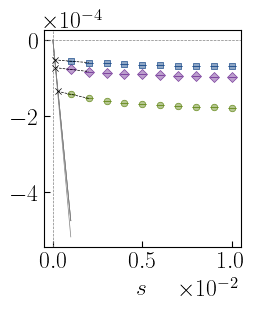

In [6]:
fig, ax = create_figure(5.0, 5.5, margin_cm=2.0)

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')

with open('figures_data/SCGF_positive_data.json', 'r') as f:
    data = json.load(f)

with open('figures_data/activity_data.json', 'r') as f:
    activity_data = json.load(f)
    a0 = activity_data[f"activity_V_{V}_L_60_large"][10]

num_sites_range = np.array([20, 40, 60])
V = 5.875

colors = ["#6B8E23", "#7A3E9D", "#1F4E8C"]
colors_soft = with_alpha(colors, 0.5)
marker_map = {20: "o", 40: "D", 60: "s"} 

for n, L in enumerate(num_sites_range):
    marker = marker_map[L]
    s_range = data[f"s_range_zoom_V_{V}"]
    SCGF_large_values = data[f"SCGF_positive_V_{V}_L_{L}_large"]
    SCGF_small_values = data[f"SCGF_positive_V_{V}_L_{L}_small"]
    errors = [abs(lv - sv) for lv, sv in zip(SCGF_large_values, SCGF_small_values)]
    ax.plot(s_range, SCGF_large_values, marker=marker, markersize=4.7, markeredgewidth=0.5, lw=0.0, c=colors[n], markerfacecolor=colors_soft[n], markeredgecolor=colors[n])
    ax.errorbar(s_range, SCGF_large_values, yerr=errors, linestyle='None', capsize=3, elinewidth=1, zorder=1, capthick=0.5, c=colors[n])
    s_range_bound = data[f"s_range_V_{V}"]
    bound = data[f"bound_V_{V}"]
    ax.plot(s_range_bound, bound, c='grey', lw=0.5)

    i0, i1 = 0, 1
    m, b = np.polyfit(s_range[i0:i1+1], SCGF_large_values[i0:i1+1], 1)
    s_cross = -b / (m + a0)
    ax.scatter(s_cross, m*s_cross + b, marker='x', s=20, lw=0.5, zorder=10, c='black')
    x = np.linspace(s_cross, s_range[i1], 100)
    ax.plot(x, m*x + b, ls='--', lw=0.5, c='black')

s_small = np.linspace(0, 0.001, 2)
ax.plot(s_small, - a0 * s_small, lw=0.5, c='grey')

ax.set_xlabel(r"$s$", fontsize=17)
ax.set_xticks([0.0, 0.005, 0.01])
ax.tick_params(axis='both', labelsize=17)

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.xaxis.offsetText.set_fontsize(17)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)


plt.savefig('figures/svg/fig3_e.svg',bbox_inches='tight',dpi=300,transparent=True)
plt.savefig('figures/pdf/fig3_e.pdf',bbox_inches='tight',dpi=300,transparent=True)
plt.show()

Intercept: 2.2534938441507654e-05 ± 2.927409757303451e-05


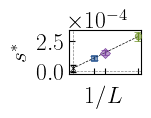

In [12]:
fig, ax = create_figure(5.5/3, 4.5/4, margin_cm=2.0/5)

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')

with open('figures_data/SCGF_positive_data.json', 'r') as f:
    data = json.load(f)

with open('figures_data/activity_data.json', 'r') as f:
    activity_data = json.load(f)
    a0 = activity_data[f"activity_V_{V}_L_60_large"][10]

num_sites_range = np.array([20, 40, 60])
V = 5.875

colors = ["#6B8E23", "#7A3E9D", "#1F4E8C"]
colors_soft = with_alpha(colors, 0.5)
marker_map = {20: "o", 40: "D", 60: "s"} 

s_cross = []; s_cross_err = []

for n, L in enumerate(num_sites_range):
    marker = marker_map[L]
    SCGF_large_values = data[f"SCGF_positive_V_{V}_L_{L}_large"]
    SCGF_small_values = data[f"SCGF_positive_V_{V}_L_{L}_small"]

    m, b = np.polyfit(s_range[:2], SCGF_large_values[:2], 1)
    sc = -b / (m + a0)
    sc_ref = - SCGF_large_values[1] / np.abs(-a0)
    s_cross.append(sc)
    s_cross_err.append(abs(sc - sc_ref))

x = 1 / np.array(num_sites_range)
y = np.array(s_cross)
sigma = np.array(s_cross_err)

def f(x, a, b):
    return a*x + b

popt, pcov = curve_fit(f, x, y, sigma=sigma, absolute_sigma=True)
a, b = popt
sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print("Intercept:", b, "±", sigma_b)


for n, L in enumerate(num_sites_range):
    ax.plot(x[n], y[n], marker=marker_map[L], markersize=4.7, markeredgewidth=0.5, lw=0.0, c=colors[n], markerfacecolor=colors_soft[n], markeredgecolor=colors[n], zorder=3)
    ax.errorbar(x[n], y[n], yerr=sigma[n], linestyle='None', capsize=3, elinewidth=1, capthick=0.5, c=colors[n], zorder=1)

x_fit = np.linspace(0, max(x), 100)
ax.plot(x_fit, f(x_fit, a, b), '--', lw=0.5, c='black')
ax.scatter(0, b, marker='x', s=10, lw=0.5, c='black', zorder=3)
ax.errorbar(0, b, yerr=sigma_b, linestyle='None', capsize=2, elinewidth=0.5, c='black', lw=0.5)

ax.set_xlabel(r'$1/L$', fontsize=17)
ax.set_ylabel(r'$s^*$', fontsize=17)
ax.set_xticks([1/60, 1/40, 1/20])
ax.set_xticklabels([])
ax.tick_params(axis='both', labelsize=17)

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

plt.savefig('figures/svg/fig3_e_inset.svg',bbox_inches='tight',dpi=300,transparent=True)
plt.savefig('figures/pdf/fig3_e_inset.pdf',bbox_inches='tight',dpi=300,transparent=True)
plt.show()